# Linear Regression & Regularization - ML Interview Prep

This notebook covers essential concepts for ML interviews:
- Linear Regression fundamentals
- Regularization techniques (Ridge, Lasso, ElasticNet)
- Practical implementation with Medical Cost dataset
- Interview practice questions

---
# Part 1: Theory
---

## 1.1 Linear Regression Fundamentals

### Model Formulation

Linear regression models the relationship between features $X$ and target $y$:

$$\hat{y} = \beta_0 + \beta_1 x_1 + \beta_2 x_2 + ... + \beta_n x_n = X\boldsymbol{\beta}$$

### Key Assumptions (LINE)

| Assumption | Description | Violation Consequence |
|------------|-------------|----------------------|
| **L**inearity | Relationship between X and y is linear | Biased estimates |
| **I**ndependence | Observations are independent | Invalid inference |
| **N**ormality | Residuals are normally distributed | Invalid confidence intervals |
| **E**qual variance (Homoscedasticity) | Constant variance of residuals | Inefficient estimates |

### Loss Function: Mean Squared Error (MSE)

$$MSE = \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2$$

### Solution Methods

**1. Normal Equation (Closed-form)**
$$\boldsymbol{\beta} = (X^T X)^{-1} X^T y$$

- Pros: Exact solution, no hyperparameters
- Cons: $O(n^3)$ complexity, fails if $X^T X$ is singular

**2. Gradient Descent**
$$\boldsymbol{\beta}_{t+1} = \boldsymbol{\beta}_t - \alpha \nabla MSE$$

- Pros: Scales to large datasets, works with non-invertible matrices
- Cons: Requires tuning learning rate, may converge slowly

## 1.2 Regularization Motivation

### The Overfitting Problem

When a model has too many features or high-magnitude coefficients:
- **Training error**: Very low
- **Test error**: High (poor generalization)

### Bias-Variance Tradeoff

$$\text{Total Error} = \text{Bias}^2 + \text{Variance} + \text{Irreducible Error}$$

| Model Complexity | Bias | Variance | Result |
|-----------------|------|----------|--------|
| Too simple | High | Low | Underfitting |
| Too complex | Low | High | Overfitting |
| Just right | Balanced | Balanced | Good generalization |

**Regularization adds bias to reduce variance**, often improving overall performance.

## 1.3 Regularization Methods Comparison

| Method | Penalty Term | Loss Function | Key Properties | Best For |
|--------|-------------|---------------|----------------|----------|
| **Ridge (L2)** | $\lambda \sum \beta_j^2$ | $MSE + \lambda \|\boldsymbol{\beta}\|_2^2$ | Shrinks coefficients toward zero (never exactly zero) | Multicollinearity, all features useful |
| **Lasso (L1)** | $\lambda \sum |\beta_j|$ | $MSE + \lambda \|\boldsymbol{\beta}\|_1$ | Produces sparse solutions (some coefficients = 0) | Feature selection, high-dimensional data |
| **ElasticNet** | $\alpha \lambda \|\boldsymbol{\beta}\|_1 + \frac{(1-\alpha)}{2} \lambda \|\boldsymbol{\beta}\|_2^2$ | Combines L1 + L2 | Balances sparsity and grouping | Correlated feature groups |

### Visual Intuition

- **L2 (Ridge)**: Constraint region is a circle/sphere - coefficients shrink smoothly
- **L1 (Lasso)**: Constraint region is a diamond - corners encourage sparsity
- **ElasticNet**: Constraint region is between circle and diamond

### Why L1 Produces Sparsity?

The L1 penalty has corners at the axes. When the contour of the loss function touches a corner, the corresponding coefficient becomes exactly zero. The L2 penalty's smooth surface rarely intersects axes exactly.

---
# Part 2: Implementation
---

## 2.1 Environment Setup & Data Loading

In [2]:
# Core libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings

# Sklearn modules
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.linear_model import RidgeCV, LassoCV, ElasticNetCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Settings
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("Environment setup complete!")

Environment setup complete!


In [3]:
def load_insurance_data(data_dir: Path = Path('data')) -> pd.DataFrame:
    """
    Load the Medical Cost Personal Dataset.
    Downloads from GitHub if not present locally.
    """
    data_dir.mkdir(exist_ok=True)
    filepath = data_dir / 'insurance.csv'
    
    if not filepath.exists():
        print("Downloading insurance dataset...")
        url = "https://raw.githubusercontent.com/stedy/Machine-Learning-with-R-datasets/master/insurance.csv"
        df = pd.read_csv(url)
        df.to_csv(filepath, index=False)
        print(f"Dataset saved to {filepath}")
    else:
        print(f"Loading dataset from {filepath}")
        df = pd.read_csv(filepath)
    
    return df

# Load data
df = load_insurance_data()
print(f"\nDataset shape: {df.shape}")
df.head()

Dataset saved to data/insurance.csv

Dataset shape: (1338, 7)


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


## 2.2 Exploratory Data Analysis (EDA)

In [4]:
# Basic info
print("=" * 50)
print("DATASET INFO")
print("=" * 50)
df.info()
print("\n" + "=" * 50)
print("MISSING VALUES")
print("=" * 50)
print(df.isnull().sum())

DATASET INFO
<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 73.3 KB

MISSING VALUES
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64


In [5]:
# Statistical summary
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [6]:
# Categorical variable distribution
cat_cols = ['sex', 'smoker', 'region']
for col in cat_cols:
    print(f"\n{col.upper()} distribution:")
    print(df[col].value_counts())


SEX distribution:
sex
male      676
female    662
Name: count, dtype: int64

SMOKER distribution:
smoker
no     1064
yes     274
Name: count, dtype: int64

REGION distribution:
region
southeast    364
southwest    325
northwest    325
northeast    324
Name: count, dtype: int64


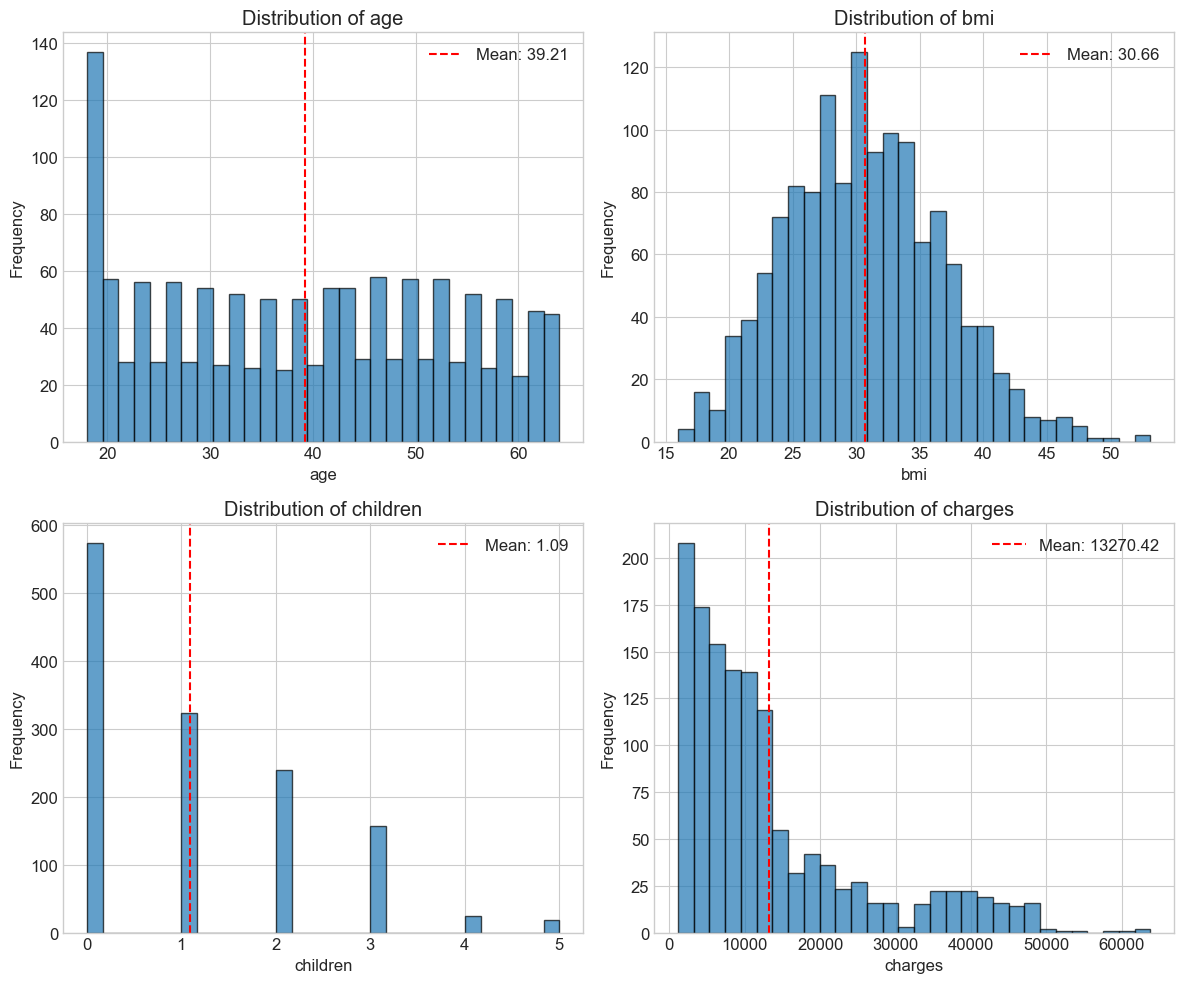

In [7]:
# Numerical features distribution
num_cols = ['age', 'bmi', 'children', 'charges']

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    axes[i].hist(df[col], bins=30, edgecolor='black', alpha=0.7)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')
    axes[i].set_title(f'Distribution of {col}')
    axes[i].axvline(df[col].mean(), color='red', linestyle='--', label=f'Mean: {df[col].mean():.2f}')
    axes[i].legend()

plt.tight_layout()
plt.show()

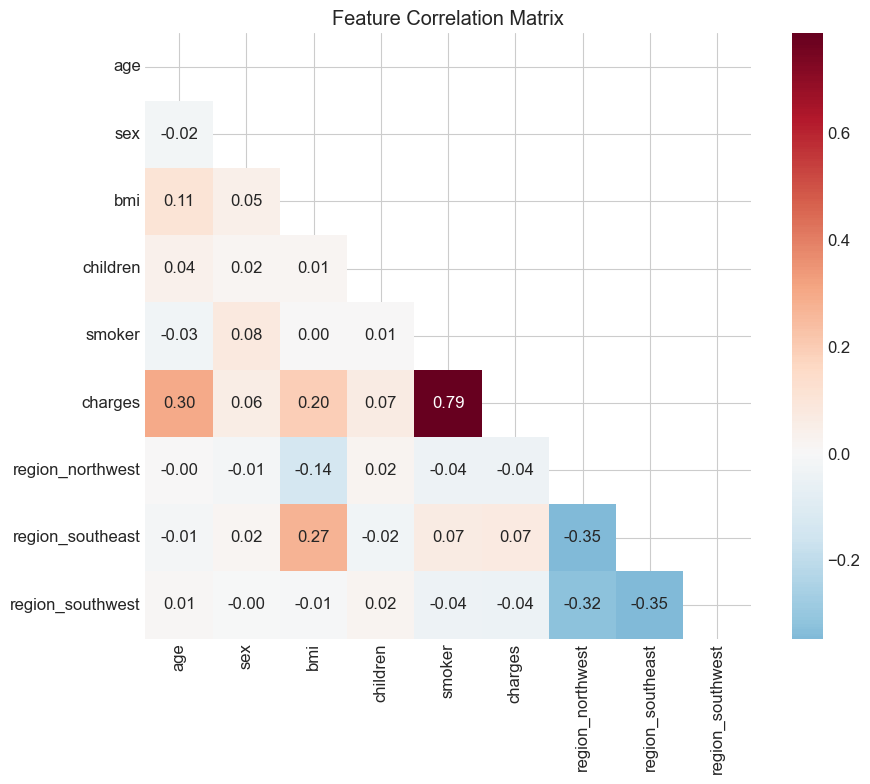

In [7]:
# Correlation matrix
# Create a copy with encoded categorical variables for correlation analysis
df_encoded = df.copy()
df_encoded['sex'] = (df['sex'] == 'male').astype(int)
df_encoded['smoker'] = (df['smoker'] == 'yes').astype(int)
df_encoded = pd.get_dummies(df_encoded, columns=['region'], drop_first=True)

plt.figure(figsize=(10, 8))
correlation = df_encoded.corr()
mask = np.triu(np.ones_like(correlation, dtype=bool))
sns.heatmap(correlation, annot=True, cmap='RdBu_r', center=0, 
            mask=mask, square=True, fmt='.2f')
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

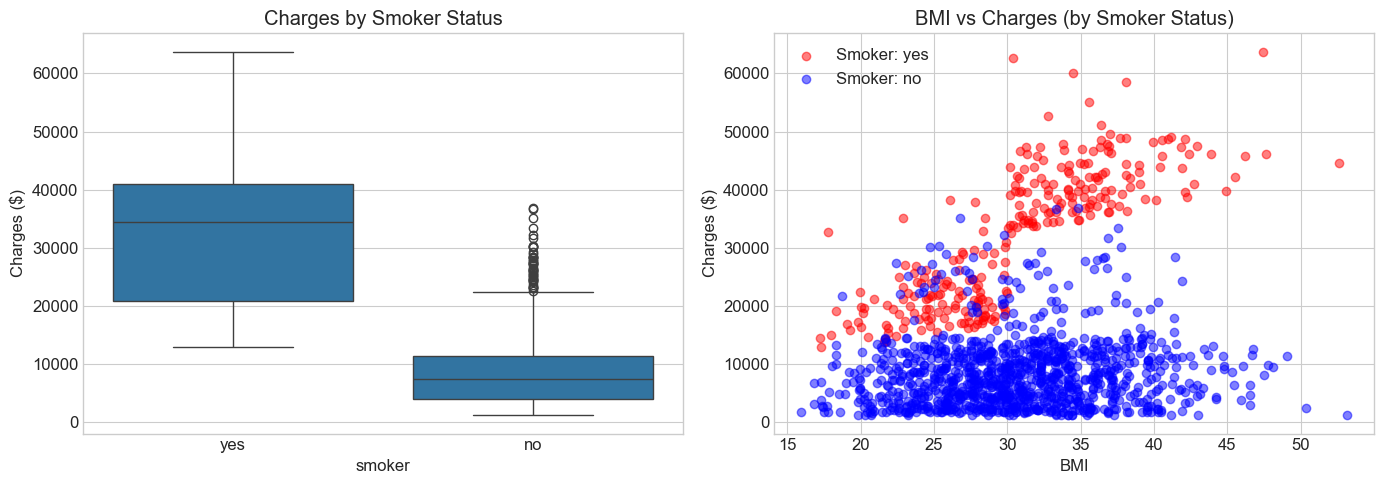

In [8]:
# Key insight: Smoker status and charges
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Smoker vs charges
sns.boxplot(x='smoker', y='charges', data=df, ax=axes[0])
axes[0].set_title('Charges by Smoker Status')
axes[0].set_ylabel('Charges ($)')

# BMI vs charges colored by smoker
colors = {'yes': 'red', 'no': 'blue'}
for smoker_status in ['yes', 'no']:
    subset = df[df['smoker'] == smoker_status]
    axes[1].scatter(subset['bmi'], subset['charges'], 
                   c=colors[smoker_status], alpha=0.5, label=f'Smoker: {smoker_status}')
axes[1].set_xlabel('BMI')
axes[1].set_ylabel('Charges ($)')
axes[1].set_title('BMI vs Charges (by Smoker Status)')
axes[1].legend()

plt.tight_layout()
plt.show()

## 2.3 Data Preprocessing

In [9]:
# Define features and target
X = df.drop('charges', axis=1)
y = df['charges']

# Identify column types
numerical_features = ['age', 'bmi', 'children']
categorical_features = ['sex', 'smoker', 'region']

print(f"Numerical features: {numerical_features}")
print(f"Categorical features: {categorical_features}")

Numerical features: ['age', 'bmi', 'children']
Categorical features: ['sex', 'smoker', 'region']


In [10]:
# Create preprocessing pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(drop='first', sparse_output=False), categorical_features)
    ]
)

# Train/Test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

print(f"Training set size: {X_train.shape[0]}")
print(f"Test set size: {X_test.shape[0]}")

Training set size: 1070
Test set size: 268


In [11]:
# Get feature names after preprocessing
def get_feature_names(preprocessor, numerical_features, categorical_features):
    """Extract feature names from fitted ColumnTransformer."""
    cat_encoder = preprocessor.named_transformers_['cat']
    cat_feature_names = cat_encoder.get_feature_names_out(categorical_features).tolist()
    return numerical_features + cat_feature_names

# Fit preprocessor to get feature names
preprocessor.fit(X_train)
feature_names = get_feature_names(preprocessor, numerical_features, categorical_features)
print(f"Feature names after preprocessing: {feature_names}")

Feature names after preprocessing: ['age', 'bmi', 'children', 'sex_male', 'smoker_yes', 'region_northwest', 'region_southeast', 'region_southwest']


## 2.4 Helper Functions

In [12]:
def evaluate_model(model, X_train, X_test, y_train, y_test, model_name="Model"):
    """
    Evaluate a regression model and return metrics.
    """
    # Predictions
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    
    # Metrics
    metrics = {
        'Model': model_name,
        'Train R²': r2_score(y_train, y_train_pred),
        'Test R²': r2_score(y_test, y_test_pred),
        'Train RMSE': np.sqrt(mean_squared_error(y_train, y_train_pred)),
        'Test RMSE': np.sqrt(mean_squared_error(y_test, y_test_pred)),
        'Train MAE': mean_absolute_error(y_train, y_train_pred),
        'Test MAE': mean_absolute_error(y_test, y_test_pred)
    }
    
    return metrics, y_test_pred


def plot_residuals(y_true, y_pred, model_name="Model"):
    """
    Plot residual analysis for a regression model.
    """
    residuals = y_true - y_pred
    
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    
    # 1. Predicted vs Actual
    axes[0].scatter(y_pred, y_true, alpha=0.5)
    axes[0].plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], 'r--', lw=2)
    axes[0].set_xlabel('Predicted')
    axes[0].set_ylabel('Actual')
    axes[0].set_title(f'{model_name}: Predicted vs Actual')
    
    # 2. Residuals vs Predicted
    axes[1].scatter(y_pred, residuals, alpha=0.5)
    axes[1].axhline(y=0, color='r', linestyle='--')
    axes[1].set_xlabel('Predicted')
    axes[1].set_ylabel('Residuals')
    axes[1].set_title(f'{model_name}: Residuals vs Predicted')
    
    # 3. Residual distribution
    axes[2].hist(residuals, bins=30, edgecolor='black', alpha=0.7)
    axes[2].axvline(x=0, color='r', linestyle='--')
    axes[2].set_xlabel('Residuals')
    axes[2].set_ylabel('Frequency')
    axes[2].set_title(f'{model_name}: Residual Distribution')
    
    plt.tight_layout()
    plt.show()


def plot_coefficients(coefs, feature_names, model_name="Model"):
    """
    Plot model coefficients as a horizontal bar chart.
    """
    coef_df = pd.DataFrame({
        'Feature': feature_names,
        'Coefficient': coefs
    }).sort_values('Coefficient', key=abs, ascending=True)
    
    plt.figure(figsize=(10, 6))
    colors = ['green' if c > 0 else 'red' for c in coef_df['Coefficient']]
    plt.barh(coef_df['Feature'], coef_df['Coefficient'], color=colors, alpha=0.7)
    plt.xlabel('Coefficient Value')
    plt.title(f'{model_name}: Feature Coefficients')
    plt.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
    plt.tight_layout()
    plt.show()
    
    return coef_df

## 2.5 Linear Regression (Baseline)

In [13]:
# Create and train Linear Regression pipeline
lr_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

lr_pipeline.fit(X_train, y_train)

# Evaluate
lr_metrics, lr_pred = evaluate_model(lr_pipeline, X_train, X_test, y_train, y_test, "Linear Regression")

print("Linear Regression Results:")
print("-" * 40)
for key, value in lr_metrics.items():
    if key != 'Model':
        print(f"{key}: {value:.4f}")

Linear Regression Results:
----------------------------------------
Train R²: 0.7417
Test R²: 0.7836
Train RMSE: 6105.5452
Test RMSE: 5796.2847
Train MAE: 4208.2346
Test MAE: 4181.1945


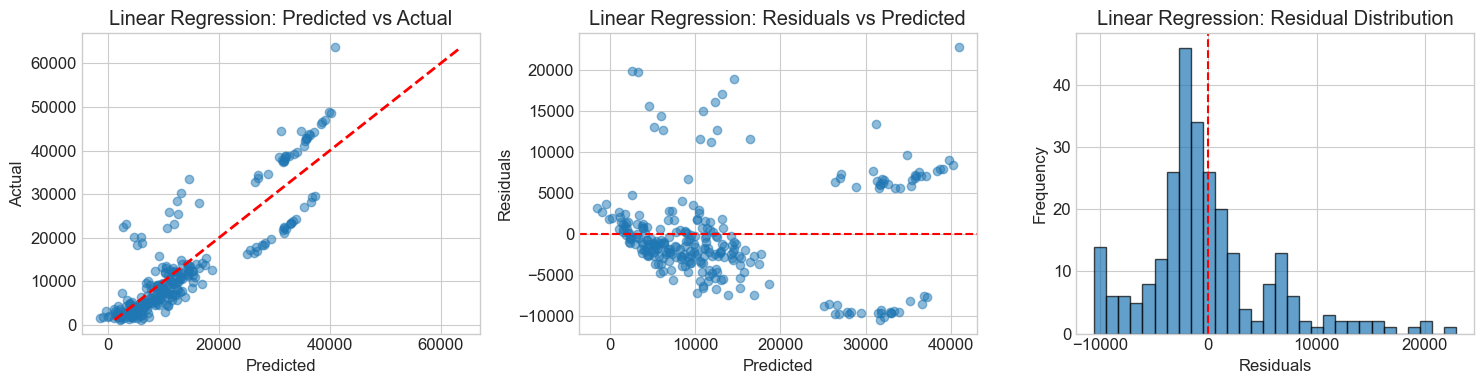

In [14]:
# Residual analysis
plot_residuals(y_test, lr_pred, "Linear Regression")

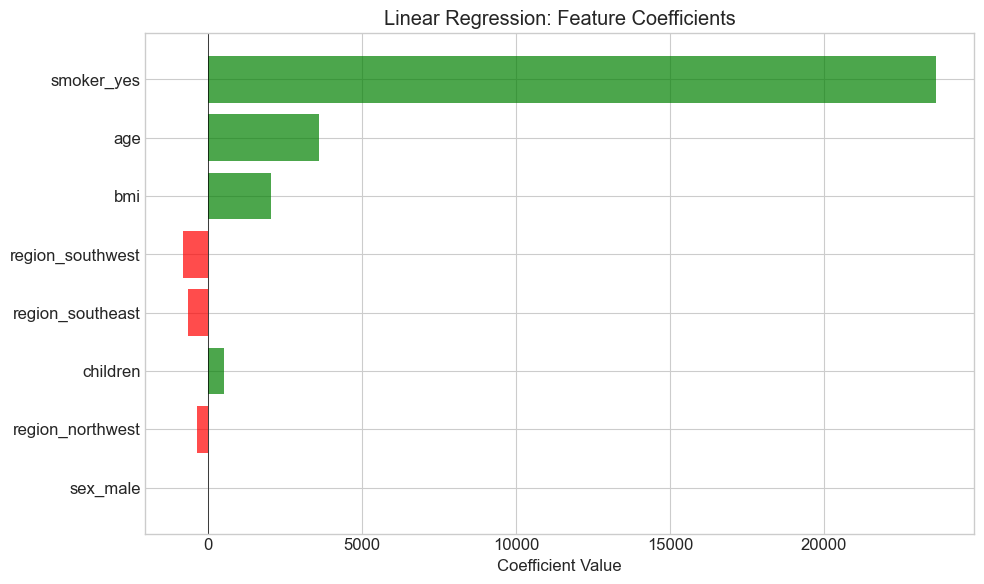


Coefficient values:
         Feature  Coefficient
        sex_male   -18.591692
region_northwest  -370.677326
        children   516.890247
region_southeast  -657.864297
region_southwest  -809.799354
             bmi  2036.228123
             age  3614.975415
      smoker_yes 23651.128856


In [15]:
# Coefficients
lr_coefs = lr_pipeline.named_steps['regressor'].coef_
lr_coef_df = plot_coefficients(lr_coefs, feature_names, "Linear Regression")
print("\nCoefficient values:")
print(lr_coef_df.to_string(index=False))

## 2.6 Ridge Regression (L2 Regularization)

In [16]:
# Preprocess data for CV models (they don't work well with Pipeline for alpha selection)
X_train_processed = preprocessor.transform(X_train)
X_test_processed = preprocessor.transform(X_test)

# Ridge with cross-validation for alpha selection
alphas = np.logspace(-3, 3, 100)
ridge_cv = RidgeCV(alphas=alphas, cv=5)
ridge_cv.fit(X_train_processed, y_train)

print(f"Best alpha (RidgeCV): {ridge_cv.alpha_:.4f}")

# Create pipeline with optimal alpha
ridge_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', Ridge(alpha=ridge_cv.alpha_))
])
ridge_pipeline.fit(X_train, y_train)

# Evaluate
ridge_metrics, ridge_pred = evaluate_model(ridge_pipeline, X_train, X_test, y_train, y_test, "Ridge")

print("\nRidge Regression Results:")
print("-" * 40)
for key, value in ridge_metrics.items():
    if key != 'Model':
        print(f"{key}: {value:.4f}")

Best alpha (RidgeCV): 1.0723

Ridge Regression Results:
----------------------------------------
Train R²: 0.7417
Test R²: 0.7833
Train RMSE: 6105.8312
Test RMSE: 5800.7849
Train MAE: 4218.1348
Test MAE: 4194.0622


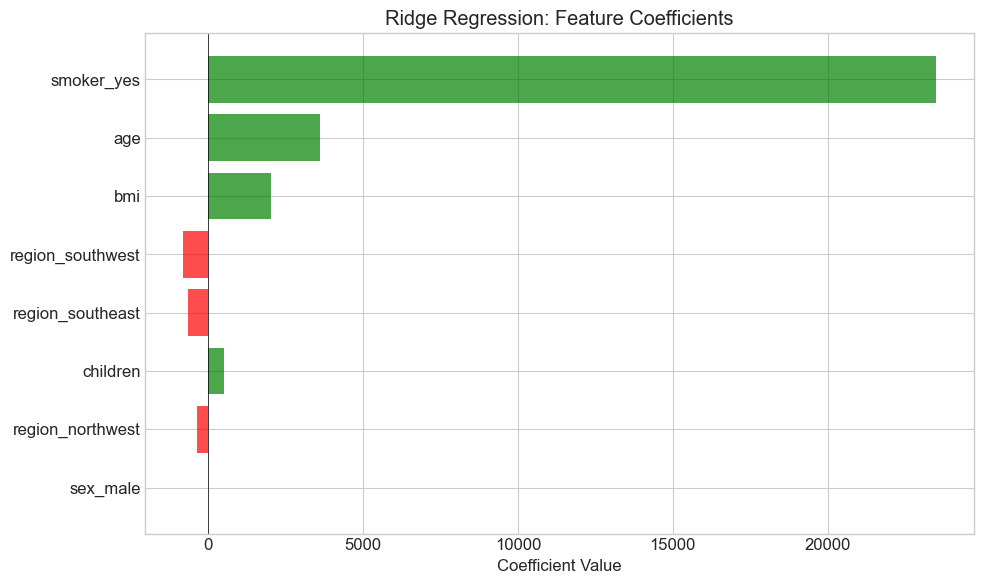

In [17]:
# Ridge coefficients
ridge_coefs = ridge_pipeline.named_steps['regressor'].coef_
ridge_coef_df = plot_coefficients(ridge_coefs, feature_names, "Ridge Regression")

## 2.7 Lasso Regression (L1 Regularization)

In [18]:
# Lasso with cross-validation for alpha selection
lasso_cv = LassoCV(alphas=alphas, cv=5, random_state=RANDOM_STATE, max_iter=10000)
lasso_cv.fit(X_train_processed, y_train)

print(f"Best alpha (LassoCV): {lasso_cv.alpha_:.4f}")

# Create pipeline with optimal alpha
lasso_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', Lasso(alpha=lasso_cv.alpha_, max_iter=10000))
])
lasso_pipeline.fit(X_train, y_train)

# Evaluate
lasso_metrics, lasso_pred = evaluate_model(lasso_pipeline, X_train, X_test, y_train, y_test, "Lasso")

print("\nLasso Regression Results:")
print("-" * 40)
for key, value in lasso_metrics.items():
    if key != 'Model':
        print(f"{key}: {value:.4f}")

Best alpha (LassoCV): 81.1131

Lasso Regression Results:
----------------------------------------
Train R²: 0.7407
Test R²: 0.7798
Train RMSE: 6117.4580
Test RMSE: 5847.3597
Train MAE: 4228.8485
Test MAE: 4240.6786


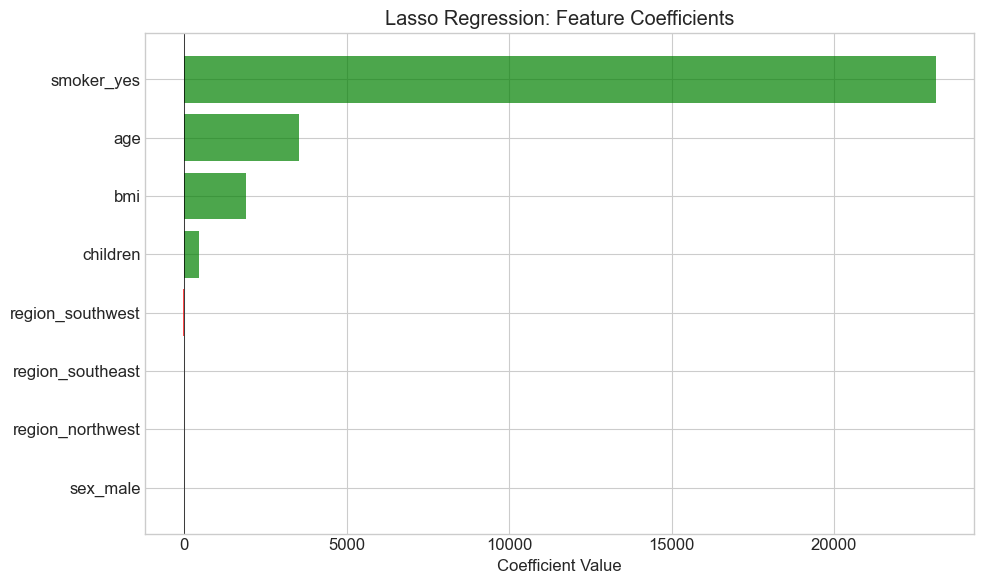


Features selected by Lasso: 5/8

Selected features:
  age: 3538.0331
  bmi: 1905.6370
  children: 445.3457
  smoker_yes: 23147.2488
  region_southwest: -33.5781


In [19]:
# Lasso coefficients - note feature selection effect
lasso_coefs = lasso_pipeline.named_steps['regressor'].coef_
lasso_coef_df = plot_coefficients(lasso_coefs, feature_names, "Lasso Regression")

# Show which features were selected (non-zero coefficients)
n_selected = np.sum(lasso_coefs != 0)
print(f"\nFeatures selected by Lasso: {n_selected}/{len(feature_names)}")
print("\nSelected features:")
for name, coef in zip(feature_names, lasso_coefs):
    if coef != 0:
        print(f"  {name}: {coef:.4f}")

## 2.8 ElasticNet Regression

In [20]:
# ElasticNet with cross-validation
l1_ratios = [0.1, 0.3, 0.5, 0.7, 0.9, 0.95, 0.99]
elastic_cv = ElasticNetCV(alphas=alphas, l1_ratio=l1_ratios, cv=5, 
                          random_state=RANDOM_STATE, max_iter=10000)
elastic_cv.fit(X_train_processed, y_train)

print(f"Best alpha (ElasticNetCV): {elastic_cv.alpha_:.4f}")
print(f"Best l1_ratio (ElasticNetCV): {elastic_cv.l1_ratio_:.2f}")

# Create pipeline with optimal parameters
elastic_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', ElasticNet(alpha=elastic_cv.alpha_, l1_ratio=elastic_cv.l1_ratio_, max_iter=10000))
])
elastic_pipeline.fit(X_train, y_train)

# Evaluate
elastic_metrics, elastic_pred = evaluate_model(elastic_pipeline, X_train, X_test, y_train, y_test, "ElasticNet")

print("\nElasticNet Regression Results:")
print("-" * 40)
for key, value in elastic_metrics.items():
    if key != 'Model':
        print(f"{key}: {value:.4f}")

Best alpha (ElasticNetCV): 0.1000
Best l1_ratio (ElasticNetCV): 0.99

ElasticNet Regression Results:
----------------------------------------
Train R²: 0.7417
Test R²: 0.7833
Train RMSE: 6105.8331
Test RMSE: 5800.8517
Train MAE: 4218.1264
Test MAE: 4194.1399


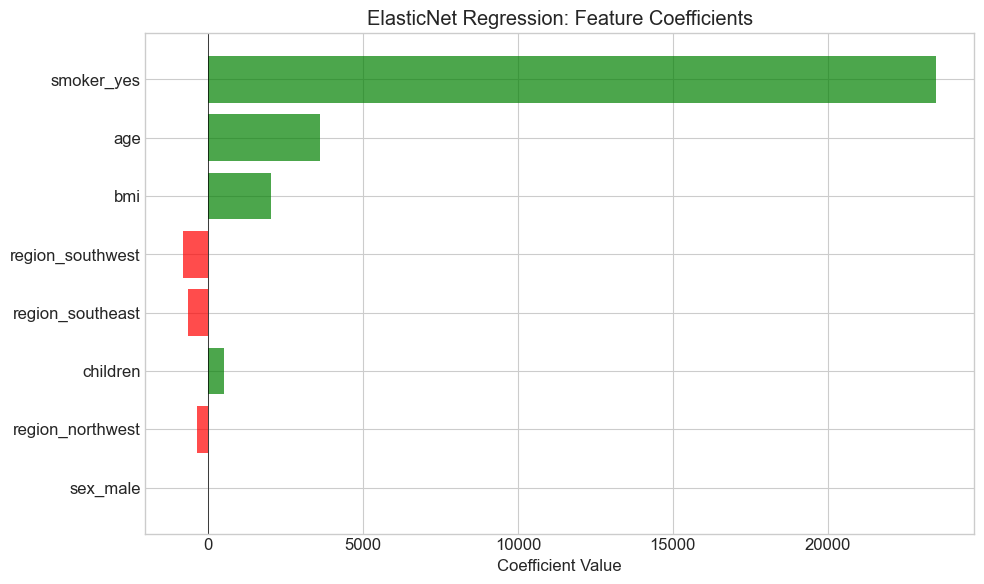

In [21]:
# ElasticNet coefficients
elastic_coefs = elastic_pipeline.named_steps['regressor'].coef_
elastic_coef_df = plot_coefficients(elastic_coefs, feature_names, "ElasticNet Regression")

## 2.9 Model Comparison

In [22]:
# Collect all metrics
all_metrics = [lr_metrics, ridge_metrics, lasso_metrics, elastic_metrics]
comparison_df = pd.DataFrame(all_metrics)
comparison_df = comparison_df.set_index('Model')

print("Model Comparison:")
print("=" * 80)
print(comparison_df.round(4).to_string())

Model Comparison:
                   Train R²  Test R²  Train RMSE  Test RMSE  Train MAE   Test MAE
Model                                                                            
Linear Regression    0.7417   0.7836   6105.5452  5796.2847  4208.2346  4181.1945
Ridge                0.7417   0.7833   6105.8312  5800.7849  4218.1348  4194.0622
Lasso                0.7407   0.7798   6117.4580  5847.3597  4228.8485  4240.6786
ElasticNet           0.7417   0.7833   6105.8331  5800.8517  4218.1264  4194.1399


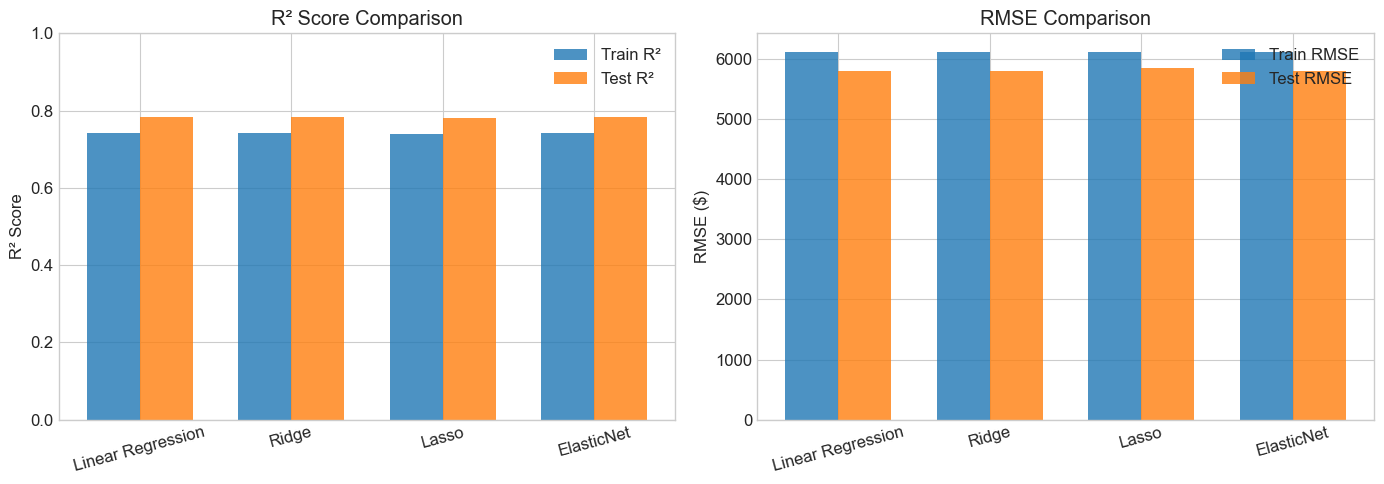

In [23]:
# Visual comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# R² comparison
models = comparison_df.index.tolist()
x_pos = np.arange(len(models))
width = 0.35

axes[0].bar(x_pos - width/2, comparison_df['Train R²'], width, label='Train R²', alpha=0.8)
axes[0].bar(x_pos + width/2, comparison_df['Test R²'], width, label='Test R²', alpha=0.8)
axes[0].set_ylabel('R² Score')
axes[0].set_title('R² Score Comparison')
axes[0].set_xticks(x_pos)
axes[0].set_xticklabels(models, rotation=15)
axes[0].legend()
axes[0].set_ylim([0, 1])

# RMSE comparison
axes[1].bar(x_pos - width/2, comparison_df['Train RMSE'], width, label='Train RMSE', alpha=0.8)
axes[1].bar(x_pos + width/2, comparison_df['Test RMSE'], width, label='Test RMSE', alpha=0.8)
axes[1].set_ylabel('RMSE ($)')
axes[1].set_title('RMSE Comparison')
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels(models, rotation=15)
axes[1].legend()

plt.tight_layout()
plt.show()

In [24]:
# Coefficient comparison across models
coef_comparison = pd.DataFrame({
    'Feature': feature_names,
    'Linear': lr_coefs,
    'Ridge': ridge_coefs,
    'Lasso': lasso_coefs,
    'ElasticNet': elastic_coefs
})

print("Coefficient Comparison:")
print(coef_comparison.round(4).to_string(index=False))

Coefficient Comparison:
         Feature     Linear      Ridge      Lasso  ElasticNet
             age  3614.9754  3608.6475  3538.0331   3608.5684
             bmi  2036.2281  2033.1410  1905.6370   2032.9359
        children   516.8902   517.6116   445.3457    517.5134
        sex_male   -18.5917   -10.0681     0.0000     -9.6381
      smoker_yes 23651.1289 23504.8318 23147.2488  23504.5015
region_northwest  -370.6773  -365.8337     0.0000   -364.2401
region_southeast  -657.8643  -641.9787    -0.0000   -640.2921
region_southwest  -809.7994  -802.4344   -33.5781   -800.8163


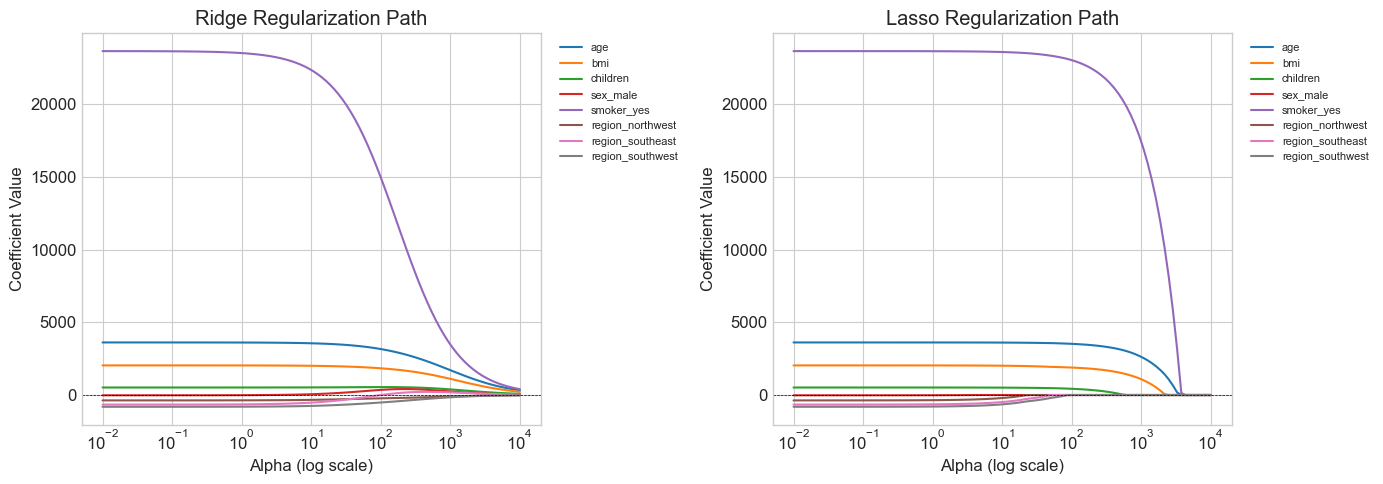

In [25]:
# Regularization path visualization
alphas_plot = np.logspace(-2, 4, 100)
ridge_coefs_path = []
lasso_coefs_path = []

for alpha in alphas_plot:
    ridge = Ridge(alpha=alpha)
    ridge.fit(X_train_processed, y_train)
    ridge_coefs_path.append(ridge.coef_)
    
    lasso = Lasso(alpha=alpha, max_iter=10000)
    lasso.fit(X_train_processed, y_train)
    lasso_coefs_path.append(lasso.coef_)

ridge_coefs_path = np.array(ridge_coefs_path)
lasso_coefs_path = np.array(lasso_coefs_path)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Ridge path
for i, name in enumerate(feature_names):
    axes[0].plot(alphas_plot, ridge_coefs_path[:, i], label=name)
axes[0].set_xscale('log')
axes[0].set_xlabel('Alpha (log scale)')
axes[0].set_ylabel('Coefficient Value')
axes[0].set_title('Ridge Regularization Path')
axes[0].axhline(y=0, color='black', linestyle='--', linewidth=0.5)
axes[0].legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)

# Lasso path
for i, name in enumerate(feature_names):
    axes[1].plot(alphas_plot, lasso_coefs_path[:, i], label=name)
axes[1].set_xscale('log')
axes[1].set_xlabel('Alpha (log scale)')
axes[1].set_ylabel('Coefficient Value')
axes[1].set_title('Lasso Regularization Path')
axes[1].axhline(y=0, color='black', linestyle='--', linewidth=0.5)
axes[1].legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)

plt.tight_layout()
plt.show()

---
# Part 3: Interview Quiz
---

Test your understanding with these common interview questions. Click to reveal answers.

### Q1: What are the four key assumptions of linear regression?

<details>
<summary>Click to reveal answer</summary>

The four key assumptions (LINE) are:

1. **Linearity**: The relationship between features and target is linear
2. **Independence**: Observations are independent of each other
3. **Normality**: Residuals are normally distributed
4. **Equal variance (Homoscedasticity)**: Residuals have constant variance across all levels of the independent variables

Violations can lead to biased estimates, invalid confidence intervals, or inefficient estimates.
</details>

### Q2: How can you tell if a model is overfitting vs underfitting?

<details>
<summary>Click to reveal answer</summary>

**Overfitting**:
- Training error is very low, but test/validation error is high
- Large gap between training and test performance
- Model is too complex, capturing noise in training data

**Underfitting**:
- Both training and test error are high
- Model is too simple to capture underlying patterns
- Small gap between training and test performance, but both are poor

**Diagnosis**: Use learning curves plotting training/validation error vs model complexity or dataset size.
</details>

### Q3: What is the key difference between L1 (Lasso) and L2 (Ridge) regularization?

<details>
<summary>Click to reveal answer</summary>

**L2 (Ridge)**:
- Penalty: $\lambda \sum \beta_j^2$
- Shrinks coefficients toward zero but never exactly to zero
- Good for multicollinearity; keeps all features

**L1 (Lasso)**:
- Penalty: $\lambda \sum |\beta_j|$
- Can shrink coefficients exactly to zero (sparse solution)
- Performs automatic feature selection
- Good for high-dimensional data with many irrelevant features

**Geometric intuition**: L1 has diamond-shaped constraint region with corners on axes, making it more likely to hit axis (zero coefficient). L2 has circular constraint region.
</details>

### Q4: When would you choose Ridge over Lasso?

<details>
<summary>Click to reveal answer</summary>

**Choose Ridge when**:
- You believe most features are relevant to the prediction
- Features are highly correlated (multicollinearity)
- You want to shrink coefficients without eliminating any
- The number of features is small to moderate

**Choose Lasso when**:
- You suspect many features are irrelevant or redundant
- You want automatic feature selection
- Interpretability is important (fewer non-zero coefficients)
- You have high-dimensional data (p >> n)

**Choose ElasticNet when**:
- You have correlated feature groups
- You want benefits of both (some sparsity + handling multicollinearity)
</details>

### Q5: Explain the Bias-Variance Tradeoff.

<details>
<summary>Click to reveal answer</summary>

Total prediction error can be decomposed as:

$$\text{Error} = \text{Bias}^2 + \text{Variance} + \text{Irreducible Error}$$

**Bias**: Error from incorrect assumptions in the model. High bias = underfitting.

**Variance**: Error from sensitivity to small fluctuations in training data. High variance = overfitting.

**Tradeoff**: 
- Simple models: High bias, low variance
- Complex models: Low bias, high variance
- Goal: Find the sweet spot that minimizes total error

**Regularization** adds controlled bias to reduce variance, often improving generalization.
</details>

### Q6: Why do we need to standardize features before applying regularization?

<details>
<summary>Click to reveal answer</summary>

**Without standardization**:
- Features with larger scales have larger coefficients
- Regularization penalty affects features unequally based on scale
- A feature measured in dollars vs cents would be penalized differently

**With standardization (mean=0, std=1)**:
- All features are on the same scale
- Regularization penalty is applied fairly across all features
- Coefficients become directly comparable in terms of feature importance

**Note**: For plain linear regression without regularization, standardization doesn't change predictions (only coefficient interpretation).
</details>

### Q7: How does the regularization parameter (alpha/lambda) affect the model?

<details>
<summary>Click to reveal answer</summary>

**Alpha = 0**: No regularization, equivalent to ordinary least squares.

**Small alpha**: 
- Weak regularization
- Coefficients close to OLS solution
- Higher variance, lower bias

**Large alpha**:
- Strong regularization
- Coefficients shrunk toward zero (Ridge) or exactly zero (Lasso)
- Lower variance, higher bias

**Alpha -> infinity**: All coefficients approach zero, model predicts the mean.

**Selection**: Use cross-validation (RidgeCV, LassoCV) to find optimal alpha.
</details>

### Q8: What is the normal equation and when would you use it vs gradient descent?

<details>
<summary>Click to reveal answer</summary>

**Normal Equation**: $\boldsymbol{\beta} = (X^T X)^{-1} X^T y$

**Use Normal Equation when**:
- Small to medium dataset (n < 10,000 features)
- $X^T X$ is invertible (no perfect multicollinearity)
- Need exact solution

**Use Gradient Descent when**:
- Large number of features (n > 10,000)
- $X^T X$ is not invertible or ill-conditioned
- Working with streaming data
- Using regularization (Ridge/Lasso have gradient-based implementations)

**Complexity**: Normal equation is O(n³), gradient descent is O(kn²) where k is iterations.
</details>

### Q9: How do you interpret coefficients in a linear regression model?

<details>
<summary>Click to reveal answer</summary>

**Without standardization**:
"A one-unit increase in feature X is associated with a β change in y, holding all other features constant."

**With standardization**:
"A one standard deviation increase in feature X is associated with a β change in y, holding all other features constant."

**Important caveats**:
- Association ≠ causation
- "Holding all other features constant" may be unrealistic for correlated features
- Multicollinearity makes individual coefficient interpretation unreliable
- With regularization, coefficients are biased (shrunk) so interpretation differs
</details>

### Q10: What is multicollinearity and how does Ridge regression help?

<details>
<summary>Click to reveal answer</summary>

**Multicollinearity**: When independent variables are highly correlated with each other.

**Problems**:
- $X^T X$ becomes nearly singular (hard to invert)
- Coefficient estimates become unstable (high variance)
- Small changes in data cause large changes in coefficients
- Difficult to interpret individual feature contributions

**How Ridge helps**:
- Adds $\lambda I$ to $X^T X$: $(X^T X + \lambda I)^{-1}$
- Ensures the matrix is always invertible
- Shrinks correlated coefficients toward each other
- Stabilizes coefficient estimates

**Detection**: Correlation matrix, VIF (Variance Inflation Factor) > 5-10 indicates multicollinearity.
</details>

### Q11: What is R² and what are its limitations?

<details>
<summary>Click to reveal answer</summary>

**R² (Coefficient of Determination)**:
$$R^2 = 1 - \frac{SS_{res}}{SS_{tot}} = 1 - \frac{\sum(y_i - \hat{y}_i)^2}{\sum(y_i - \bar{y})^2}$$

**Interpretation**: Proportion of variance in y explained by the model. R²=0.8 means 80% of variance is explained.

**Limitations**:
- Always increases when adding features (use Adjusted R² instead)
- Can be misleading for non-linear relationships
- Doesn't indicate if correct model is used
- Doesn't indicate prediction accuracy in absolute terms
- Can be negative for very poor models (worse than predicting mean)

**Better practice**: Report multiple metrics (R², RMSE, MAE) and examine residual plots.
</details>

### Q12: What is the l1_ratio parameter in ElasticNet?

<details>
<summary>Click to reveal answer</summary>

**l1_ratio** controls the mix between L1 and L2 penalties:

$$\text{Penalty} = \alpha \cdot l1\_ratio \cdot ||\beta||_1 + \alpha \cdot \frac{(1 - l1\_ratio)}{2} \cdot ||\beta||_2^2$$

**Values**:
- `l1_ratio = 0`: Pure Ridge (L2 only)
- `l1_ratio = 1`: Pure Lasso (L1 only)
- `l1_ratio = 0.5`: Equal mix of L1 and L2

**Typical values**: 0.1 to 0.9. Use cross-validation to find optimal value.

**Use case**: When you want some feature selection (L1) but also stability for correlated features (L2).
</details>

### Q13: How would you handle categorical variables in linear regression?

<details>
<summary>Click to reveal answer</summary>

**One-Hot Encoding (most common)**:
- Create binary (0/1) columns for each category
- Drop one category to avoid multicollinearity (dummy variable trap)
- Example: Region {NE, NW, SE, SW} → 3 binary columns

**Label Encoding** (ordinal only):
- Assign integers: Low=1, Medium=2, High=3
- Only appropriate when categories have natural ordering

**Target Encoding** (advanced):
- Replace category with mean of target for that category
- Risk of data leakage; use with cross-validation

**sklearn approach**: Use `ColumnTransformer` with `OneHotEncoder(drop='first')` for dummy encoding.
</details>

### Q14: What metrics would you use to evaluate a regression model?

<details>
<summary>Click to reveal answer</summary>

| Metric | Formula | Use Case |
|--------|---------|----------|
| **MSE** | $\frac{1}{n}\sum(y-\hat{y})^2$ | Penalizes large errors heavily |
| **RMSE** | $\sqrt{MSE}$ | Same units as target, interpretable |
| **MAE** | $\frac{1}{n}\sum|y-\hat{y}|$ | Robust to outliers |
| **R²** | $1 - \frac{SS_{res}}{SS_{tot}}$ | Proportion of variance explained |
| **Adjusted R²** | Penalized for # features | Compare models with different features |
| **MAPE** | $\frac{100}{n}\sum|\frac{y-\hat{y}}{y}|$ | Percentage error, business-friendly |

**Best practice**: Report multiple metrics and compare train vs test to detect overfitting.
</details>

### Q15: Why might a linear regression model have negative coefficients for positively correlated features?

<details>
<summary>Click to reveal answer</summary>

**This is often due to multicollinearity!**

**Example scenario**:
- Features A and B are both positively correlated with y individually
- A and B are also highly correlated with each other
- In multiple regression, the model might assign a negative coefficient to one

**Why it happens**:
- Coefficients represent the effect of a feature while holding others constant
- When features are correlated, this "holding constant" interpretation breaks down
- The model distributes the shared effect arbitrarily between correlated features

**Solutions**:
- Use regularization (Ridge handles this well)
- Remove one of the correlated features
- Use PCA to create uncorrelated components
- Check VIF and correlation matrix before interpreting coefficients
</details>

---
## Summary

In this notebook, we covered:

1. **Linear Regression Theory**: Assumptions, loss functions, solution methods
2. **Regularization**: Ridge (L2), Lasso (L1), ElasticNet and when to use each
3. **Practical Implementation**: Full pipeline from data loading to model comparison
4. **Interview Prep**: 15 common questions with detailed answers

### Key Takeaways

- Always check regression assumptions (residual plots)
- Standardize features before regularization
- Use cross-validation to select hyperparameters
- Choose regularization based on your goals (feature selection vs stability)
- Report multiple metrics and compare train vs test performance